# Bellabeat Smart Device Usage Case Study

## Introduction

Bellabeat is a wellness technology company that develops smart products designed to help users understand their activity, sleep and other health habits.

This case study analyses Fitbit smart-device usage data to identify behavioural trends that could provide useful insights for Bellabeat.

## Business Task

Analyse smart-device usage trends from Fitbit user data and consider how these trends may apply to Bellabeat customers. Use the insights from this analysis to develop high-level marketing recommendations for the Bellabeat Time wellness watch.

### Key Questions

1. What trends can be identified in smart-device activity and sleep behaviour?
2. How might these trends apply to Bellabeat customers?
3. How could these insights inform Bellabeat's strategy?

## Tools & Libraries

This analysis was completed in Python using pandas for data preparation and analysis, NumPy for simple numerical calculations, and Matplotlib for visualisation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Prepare & Process

The source Fitbit dataset contains records collected across two periods between March and May 2016. This case study focuses on **12 April to 12 May 2016**, which provides directly comparable daily activity and daily sleep data for a consistent one-month analysis window.

The Fitbit records were collected in 2016, as supplied for this case study.

The following preparation steps assess the structure, completeness and quality of the data used in the main analysis.

## Main Analysis Dataset — 12 April to 12 May 2016

The main dataset contains daily sleep and daily activity records for the selected one-month analysis period.


In [2]:
sleep_daily = pd.read_csv(
    r"..\data\raw\fitbit_2016-04-12_to_2016-05-12\sleepDay_merged.csv"
)

In [3]:
sleep_daily.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [4]:
sleep_daily["SleepDay"] = pd.to_datetime(
    sleep_daily["SleepDay"],
    format="%m/%d/%Y %I:%M:%S %p"
)

In [5]:
sleep_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id                  413 non-null    int64         
 1   SleepDay            413 non-null    datetime64[us]
 2   TotalSleepRecords   413 non-null    int64         
 3   TotalMinutesAsleep  413 non-null    int64         
 4   TotalTimeInBed      413 non-null    int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 16.3 KB


### Sleep-data validation

The daily sleep table was checked for missing values and exact duplicates. Three duplicate rows were removed. Extremely short sleep records were also inspected; because there was insufficient evidence that they were data-entry errors, they were retained and treated as a limitation.

In [6]:
sleep_daily.duplicated().sum()

np.int64(3)

In [7]:
sleep_daily.isnull().sum()

Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64

In [8]:
sleep_daily = sleep_daily.drop_duplicates()
print("Rows after duplicate removal:", sleep_daily.shape[0])
print("Remaining duplicates:", sleep_daily.duplicated().sum())

Rows after duplicate removal: 410
Remaining duplicates: 0


In [9]:
sleep_daily.describe()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.100000e+02,410,410.000000,410.000000,410.000000
mean,4.994963e+09,2016-04-26 11:38:55.609756,1.119512,419.173171,458.482927
min,1.503960e+09,2016-04-12 00:00:00,1.000000,58.000000,61.000000
25%,3.977334e+09,2016-04-19 00:00:00,1.000000,361.000000,403.750000
50%,4.702922e+09,2016-04-27 00:00:00,1.000000,432.500000,463.000000
75%,6.962181e+09,2016-05-04 00:00:00,1.000000,490.000000,526.000000
max,8.792010e+09,2016-05-12 00:00:00,3.000000,796.000000,961.000000
std,2.060863e+09,NaN,0.346636,118.635918,127.455140


In [10]:
sleep_daily.sort_values("TotalMinutesAsleep").head(10)

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
338,7007744171,2016-05-01,1,58,61
123,4319703577,2016-04-21,1,59,65
65,2320127002,2016-04-23,1,61,69
164,4388161847,2016-05-09,1,62,65
282,5577150313,2016-05-05,1,74,78
365,8053475328,2016-05-07,1,74,75
110,4020332650,2016-04-16,1,77,77
337,7007744171,2016-04-16,1,79,82
150,4388161847,2016-04-22,1,82,85
172,4445114986,2016-04-17,1,98,107


In [11]:
activity_daily = pd.read_csv(
    r"..\data\raw\fitbit_2016-04-12_to_2016-05-12\dailyActivity_merged.csv"
)

In [12]:
activity_daily.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [13]:
activity_daily["ActivityDate"] = pd.to_datetime(activity_daily["ActivityDate"])

print("Unique users:", activity_daily["Id"].nunique())
print("Date range:", activity_daily["ActivityDate"].min(), "to", activity_daily["ActivityDate"].max())
print("Duplicate rows:", activity_daily.duplicated().sum())
print("Null values:")
print(activity_daily.isnull().sum())

Unique users: 33
Date range: 2016-04-12 00:00:00 to 2016-05-12 00:00:00
Duplicate rows: 0
Null values:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64


In [14]:
activity_daily.describe()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,9.400000e+02,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,2016-04-26 06:53:37.021276,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574
min,1.503960e+09,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000
50%,4.445115e+09,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000
75%,6.962181e+09,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000
max,8.877689e+09,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000
std,2.424805e+09,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862


### Activity-data quality investigation

Records with exactly 1,440 sedentary minutes were investigated because this represents a full 24-hour day. Most of these records also had zero steps, while a small number contained substantial step counts but zero recorded active minutes. Zero-calorie records were also identified.

These observations suggest incomplete or inconsistent tracking in some activity-intensity fields. The records were not automatically removed because other fields, particularly `TotalSteps`, could still contain useful information. The final analysis therefore prioritises step count and treats the affected activity-intensity fields cautiously.

In [15]:
full_sedentary_day = activity_daily["SedentaryMinutes"] == 1440
print("Records with 1,440 sedentary minutes:", full_sedentary_day.sum())

zero_steps_full_sedentary = (
    (activity_daily["TotalSteps"] == 0) &
    (activity_daily["SedentaryMinutes"] == 1440)
)
print("Of these, records with zero steps:", zero_steps_full_sedentary.sum())

Records with 1,440 sedentary minutes: 79
Of these, records with zero steps: 72


In [16]:
activity_daily[
    (activity_daily["TotalSteps"] > 0) &
    (activity_daily["SedentaryMinutes"] == 1440)
]

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
381,4319703577,2016-04-12,7753,5.20,5.20,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,2115
412,4388161847,2016-04-12,10122,7.78,7.78,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,2955
853,8583815059,2016-04-16,5319,4.15,4.15,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,2693
854,8583815059,2016-04-17,3008,2.35,2.35,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,2439
869,8583815059,2016-05-02,8469,6.61,6.61,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,2894
870,8583815059,2016-05-03,12015,9.37,9.37,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,3212
871,8583815059,2016-05-04,3588,2.80,2.80,0.0,0.0,0.0,0.0,0.0,0,0,0,1440,2516


In [17]:
print("Records with zero calories:", (activity_daily["Calories"] == 0).sum())

Records with zero calories: 4


## Analysis Scope

The main analysis covers **12 April to 12 May 2016** and examines daily step activity, sleep duration, and the relationship between the two where user-date records align.

The analysis prioritises `TotalSteps` and `TotalMinutesAsleep`. Activity-intensity fields affected by the data-quality issues identified above are treated cautiously.

The earlier March–April period also contains activity and sleep data, but its sleep file records each minute as **asleep, restless or awake** instead of providing a ready-made daily sleep-duration measure. To use it in the same analysis, those minute-level records would need to be aggregated and the mapping to a daily `TotalMinutesAsleep` measure would need to be confirmed. Rather than make that assumption, this project uses the later one-month period, where daily activity and sleep measures are already directly comparable. The earlier period could be revisited in a follow-up analysis once the metric definition is confirmed.

# Analyse

The analysis addresses three questions:

1. How do daily activity levels vary across users and days of the week?
2. What patterns are visible in sleep duration and sleep-data coverage?
3. Is daily step count meaningfully associated with sleep duration?

## Activity Patterns

### Initial Step Summary

- Mean daily steps: approximately 7,638
- Median daily steps: approximately 7,406
- 25% of recorded days had 3,790 steps or fewer.
- Daily step counts show substantial variation, with a standard deviation of approximately 5,082 steps.
- Zero-step records and unusually high values are present and should be interpreted with the data-quality limitations identified during preparation.

### Steps by Day of Week

Average daily steps were relatively consistent across the week. Saturday (8,153) and Tuesday (8,125) recorded the highest average step counts, while Sunday had the lowest average at 6,933 steps.

There was no clear overall weekday-versus-weekend pattern, although Sunday showed noticeably lower activity than the other days.

Users showed considerable differences in their typical activity levels. The median user averaged approximately 7,283 steps per day, while the middle 50% of users averaged between approximately 5,567 and 9,520 steps. Individual user averages ranged widely, from 916 to 16,040 steps per day.

In [18]:
activity_daily["TotalSteps"].describe()

count      940.000000
mean      7637.910638
std       5087.150742
min          0.000000
25%       3789.750000
50%       7405.500000
75%      10727.000000
max      36019.000000
Name: TotalSteps, dtype: float64

In [19]:
activity_days_by_user = activity_daily.groupby("Id")["ActivityDate"].count()
activity_days_by_user.describe().round(2)

count    33.00
mean     28.48
std       5.66
min       4.00
25%      29.00
50%      31.00
75%      31.00
max      31.00
Name: ActivityDate, dtype: float64

In [20]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

activity_daily["DayOfWeek"] = activity_daily["ActivityDate"].dt.day_name()

avg_steps_by_day = (
    activity_daily.groupby("DayOfWeek")["TotalSteps"]
    .mean()
    .reindex(day_order)
)

avg_steps_by_day.round(2)

DayOfWeek
Monday       7780.87
Tuesday      8125.01
Wednesday    7559.37
Thursday     7405.84
Friday       7448.23
Saturday     8152.98
Sunday       6933.23
Name: TotalSteps, dtype: float64

In [21]:
avg_steps_by_user = activity_daily.groupby("Id")["TotalSteps"].mean()
avg_steps_by_user.describe().round(2)

count       33.00
mean      7519.27
std       3576.34
min        916.13
25%       5566.87
50%       7282.97
75%       9519.67
max      16040.03
Name: TotalSteps, dtype: float64

### Average Steps by Day of Week

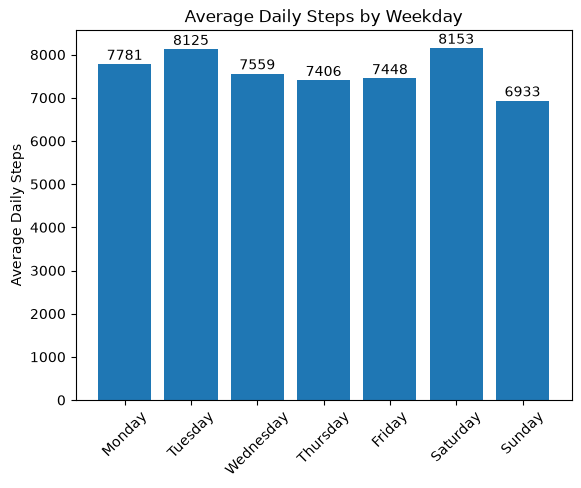

In [22]:
plt.bar(
    avg_steps_by_day.index,
    avg_steps_by_day.values
)
for i, value in enumerate(avg_steps_by_day.values):
    plt.text(i, value + 100, f"{value:.0f}", ha="center")
plt.ylabel("Average Daily Steps")
plt.title("Average Daily Steps by Weekday")
plt.xticks(rotation=45)
plt.show()

## Sleep Patterns

Sleep duration was analysed both across individual sleep records and across days of the week. User-level record counts were also reviewed because sleep-data coverage varied substantially between participants.

In [23]:
(sleep_daily["TotalMinutesAsleep"] / 60).describe().round(2)

count    410.00
mean       6.99
std        1.98
min        0.97
25%        6.02
50%        7.21
75%        8.17
max       13.27
Name: TotalMinutesAsleep, dtype: float64

In [24]:
sleep_records_by_user = sleep_daily.groupby("Id")["SleepDay"].count()
sleep_records_by_user.describe().round(0)

count    24.0
mean     17.0
std      11.0
min       1.0
25%       5.0
50%      20.0
75%      27.0
max      31.0
Name: SleepDay, dtype: float64

### Sleep Summary

- Across all 410 sleep records, mean sleep duration was approximately 419 minutes (7.0 hours), with a median of approximately 433 minutes (7.2 hours).
- The sleep data covers 24 users.
- The middle 50% of sleep records ranged from approximately 6.0 to 8.2 hours.
- Sleep data coverage varies substantially between users, with some users contributing only 1–5 sleep records while others contributed close to a full month.
- Therefore, individual user sleep averages should be interpreted cautiously, particularly for users with very few recorded nights.

### Sleep by Day of Week

Average sleep duration was fairly consistent across the week, generally between about 6.7 and 7.5 hours.

Sleep events beginning Sunday had the highest average sleep duration at approximately 453 minutes (7.5 hours), while sleep events beginning Thursday had the lowest at approximately 401 minutes (6.7 hours).

In [25]:
sleep_daily["SleepDayOfWeek"] = sleep_daily["SleepDay"].dt.day_name()

avg_sleep_by_day = (
    sleep_daily.groupby("SleepDayOfWeek")["TotalMinutesAsleep"]
    .mean()
    .reindex(day_order)
)

(avg_sleep_by_day / 60).round(2)

SleepDayOfWeek
Monday       6.99
Tuesday      6.74
Wednesday    7.24
Thursday     6.69
Friday       6.76
Saturday     6.98
Sunday       7.55
Name: TotalMinutesAsleep, dtype: float64

### Average Sleep Duration by Day of Week

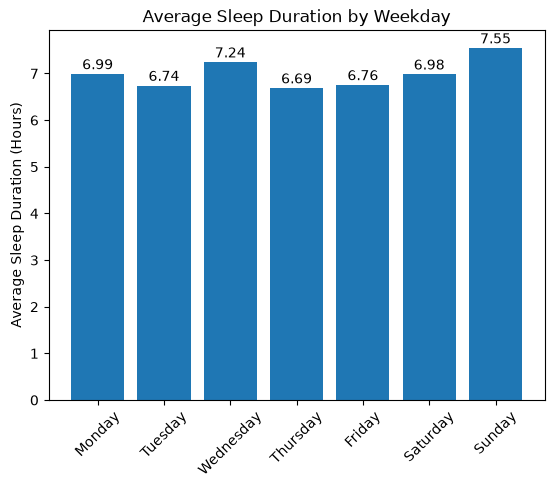

In [26]:
plt.bar(
    avg_sleep_by_day.index,
    avg_sleep_by_day.values /60
)
for i, value in enumerate(avg_sleep_by_day.values / 60):
    plt.text(i, value + 0.1, f"{value:.2f}", ha="center")
plt.ylabel("Average Sleep Duration (Hours)")
plt.title("Average Sleep Duration by Weekday")
plt.xticks(rotation=45)
plt.show()

## Activity and Sleep Relationship

Daily activity and sleep records were matched by user and date to examine whether step count during a day was associated with sleep duration recorded for the corresponding sleep period. A next-day relationship was also explored as a secondary check.

Correlation is used here only to describe association; it does not imply causation.

In [27]:
activity_sleep_same_day = sleep_daily.merge(
    activity_daily,
    left_on=["Id", "SleepDay"],
    right_on=["Id", "ActivityDate"],
    how="inner"
)

print("Matched same-day records:", activity_sleep_same_day.shape[0])

Matched same-day records: 410


In [28]:
same_day_correlation = activity_sleep_same_day["TotalMinutesAsleep"].corr(
    activity_sleep_same_day["TotalSteps"]
)
round(same_day_correlation, 2)

np.float64(-0.19)

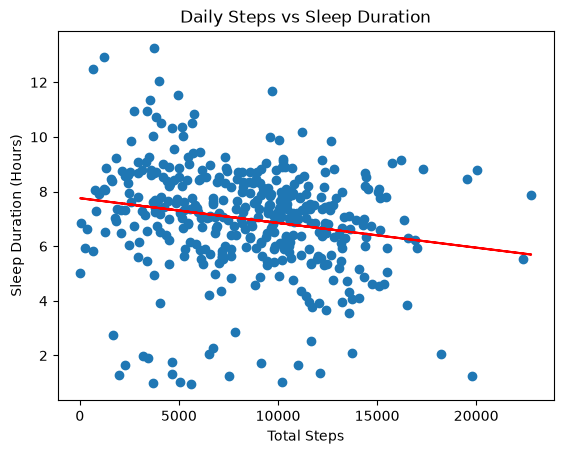

In [29]:


x = activity_sleep_same_day["TotalSteps"]
y = activity_sleep_same_day["TotalMinutesAsleep"] / 60

plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b, color='red')

plt.xlabel("Total Steps")
plt.ylabel("Sleep Duration (Hours)")
plt.title("Daily Steps vs Sleep Duration")
plt.show()

### Relationship Between Activity and Sleep

Two relationships were explored:

- Sleep duration and total steps on the following day showed a weak negative correlation (`r ≈ -0.15`).
- Total steps during the day and sleep duration that night also showed a weak negative correlation (`r ≈ -0.19`).

Scatter plots showed substantial variation and no strong linear relationship between daily step count and sleep duration.

Overall, the Period 2 data does not provide evidence of a strong relationship between sleep duration and daily step count in either direction. These results show association only and should not be interpreted as causal.

## Key Findings

### 1. Activity Patterns

Weekday activity was relatively consistent, at roughly 7,000–8,000 average daily steps. Average activity was slightly higher on Tuesdays and Saturdays with over 8,000 average daily steps. Sunday saw a lower daily average at roughly 6,900 steps.

Despite the relatively stable weekday averages, there was substantial variation between users: 25% of users averaged below roughly 5,500 daily steps, while the top 25% averaged above roughly 9,500 daily steps.

### 2. Sleep Patterns

Average sleep duration was relatively consistent across the week, with only modest differences between weekdays. Sunday recorded the highest average sleep duration at 7.55 hours, while Thursday recorded the lowest at 6.69 hours. Sleep-data coverage varied considerably between users, so these weekday averages should be interpreted cautiously.

### 3. Steps vs Sleep Relationship

Upon analysis, there was a very weak negative correlation between daily steps and daily sleep duration. This means we tended to see slightly lower sleep durations on days with higher activity.

However, the correlation was very weak (r = -0.19), and the observations showed substantial variation. Therefore, the data does not provide strong evidence of a meaningful relationship between daily steps and sleep duration.

## Recommendations

### 1. Personalised Activity Goals

Daily activity was relatively consistent across weekdays, but activity levels varied substantially between individual users. Bellabeat could therefore provide personalised activity goals and benchmarks based on each user's own historical activity rather than relying primarily on generic step targets. Personalised goals could provide users with more achievable and relevant targets as their activity levels change over time.

### 2. Encourage Consistent Sleep Tracking

Sleep data coverage varied substantially between users, with some users recording close to a full month of sleep data while others recorded only a few nights. Bellabeat could encourage regular sleep tracking through reminders and educational messaging that explains how more complete data enables meaningful personalised insights and trends over time.

This could include in-app or wearable reminders for users whose sleep data has not been recorded consistently.

### 3. Treat Activity and Sleep as Distinct Wellness Measures

The analysis found only a very weak relationship between daily steps and sleep duration (r = -0.19). Bellabeat should therefore avoid assuming that highly active users will necessarily have longer sleep. Activity and sleep could instead be monitored as distinct wellness measures, allowing users to receive insights based on their actual sleep patterns rather than their activity levels alone.

## Limitations

### 1. Small sample size
The dataset contains 33 users with activity data and 24 users with sleep data. This is a small sample from which to make claims about a much larger Bellabeat customer base.

### 2. Short observation period
The main analysis covers roughly one month. A longer observation period could provide greater confidence in long-term behavioural patterns, account for seasonal variation and reduce the influence of short-term fluctuations.

### 3. Incomplete / Questionable records
The amount of data provided by different users varied considerably, particularly for sleep data. The analysis also identified unusual observations such as extremely short sleep durations and zero-calorie days. Their causes could not be confirmed, which reduces confidence in some of the data.

### 4. Limited demographic information
The age, gender, location and other demographic characteristics of the Fitbit users are unknown. This is particularly relevant because Bellabeat targets women, so the findings cannot be assumed to represent Bellabeat's customer base.

### 5. Historical dataset
The Fitbit data was collected in 2016. In a real business setting, current user data would be needed before using these findings to guide marketing decisions in 2026.

## Conclusion

The analysis found that average activity and sleep patterns were relatively stable across the week, but individual activity levels varied widely and sleep-data coverage differed considerably between users. Daily steps and sleep duration showed only a very weak relationship, suggesting that activity and sleep should be treated as distinct wellness measures rather than using one as a proxy for the other.

For Bellabeat, the clearest opportunities from this analysis are to personalise activity goals using users' own historical behaviour, encourage more consistent sleep tracking, and provide activity and sleep insights independently.

These recommendations should be interpreted within the limitations of the small sample, short observation period, incomplete records, limited demographic information and the historical nature of the dataset.